# Model Embedding Visualization

Purpose: visualize the Milestone 10 RF embedding research path with PCA clusters and placeholder training losses.

Run path: `uv sync --extra research`, then open this notebook with `uv run jupyter lab notebooks` and run all cells. The notebook intentionally avoids requiring torch.

Fixture / simulated source: deterministic synthetic embeddings for empty, present, motion, and room states, plus synthetic contrastive and calibration loss curves.

Expected interpretation: PCA should separate the four synthetic clusters, and the training curves should decline smoothly while retaining a small validation gap.

Limitations: these embeddings are generated from formulas, not from a learned RF encoder. The plot is useful for checking visualization contracts, not model quality.


In [1]:
import importlib

import matplotlib.pyplot as plt
import numpy as np

try:
    from sklearn.decomposition import PCA as SklearnPCA
    pca_backend = "sklearn"
except Exception as exc:
    SklearnPCA = None
    pca_backend = f"numpy-svd fallback ({type(exc).__name__}: {exc})"

try:
    ruview_nn = importlib.import_module("ruview.nn")
    nn_note = "ruview.nn import ok; synthetic embeddings still use local NumPy helpers"
except Exception as exc:
    ruview_nn = None
    nn_note = f"Fallback embedding path: {type(exc).__name__}: {exc}"

print({"pca_backend": pca_backend, "nn_note": nn_note})


{'pca_backend': 'sklearn', 'nn_note': 'ruview.nn import ok; synthetic embeddings still use local NumPy helpers'}


In [2]:
CLUSTERS = ("empty", "present", "motion", "room")
COLORS = {
    "empty": "#4c78a8",
    "present": "#59a14f",
    "motion": "#e15759",
    "room": "#b07aa1",
}


def make_synthetic_embeddings(samples_per_cluster=18, embedding_dim=12):
    centers = {
        "empty": np.array([-2.0, -0.8, 0.2, 0.0, 0.3, -0.1, 0.2, 0.0, -0.3, 0.1, 0.0, 0.2]),
        "present": np.array([0.0, 1.9, 0.4, -0.2, 0.2, 0.5, -0.1, 0.3, 0.0, -0.2, 0.2, 0.1]),
        "motion": np.array([2.1, 0.3, -0.6, 0.4, -0.2, 0.1, 0.5, -0.3, 0.2, 0.2, -0.1, 0.0]),
        "room": np.array([-0.2, -2.0, 0.8, 0.3, -0.4, 0.2, -0.2, 0.5, 0.1, -0.1, 0.4, -0.3]),
    }
    rows = []
    labels = []
    rooms = []
    basis = np.arange(embedding_dim, dtype=float)

    for cluster_id, label in enumerate(CLUSTERS):
        center = centers[label]
        for sample_id in range(samples_per_cluster):
            room_id = sample_id % 3
            angle = 0.37 * sample_id + 0.61 * cluster_id
            deterministic_jitter = 0.075 * np.sin((basis + 1.0) * angle)
            room_offset = 0.055 * (room_id - 1) * np.cos((basis + 2.0) * 0.4)
            rows.append(center + deterministic_jitter + room_offset)
            labels.append(label)
            rooms.append(room_id)

    return np.vstack(rows), np.array(labels), np.array(rooms)


def pca_2d(embeddings):
    if SklearnPCA is not None:
        model = SklearnPCA(n_components=2)
        coords = model.fit_transform(embeddings)
        explained = model.explained_variance_ratio_
        return coords, explained

    centered = embeddings - embeddings.mean(axis=0, keepdims=True)
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    coords = centered @ vt[:2].T
    explained = singular_values[:2] ** 2 / np.sum(singular_values**2)
    return coords, explained


def synthetic_training_curves(num_epochs=20):
    epochs = np.arange(1, num_epochs + 1)
    contrastive = 0.92 * np.exp(-epochs / 6.0) + 0.10 + 0.014 * np.sin(epochs * 0.8)
    calibration = 0.42 * np.exp(-epochs / 8.0) + 0.045 + 0.008 * np.cos(epochs * 0.6)
    projection = 0.55 * np.exp(-epochs / 7.2) + 0.070 + 0.010 * np.sin(epochs * 0.4 + 0.5)
    total = 0.55 * contrastive + 0.25 * calibration + 0.20 * projection
    return epochs, contrastive, calibration, projection, total


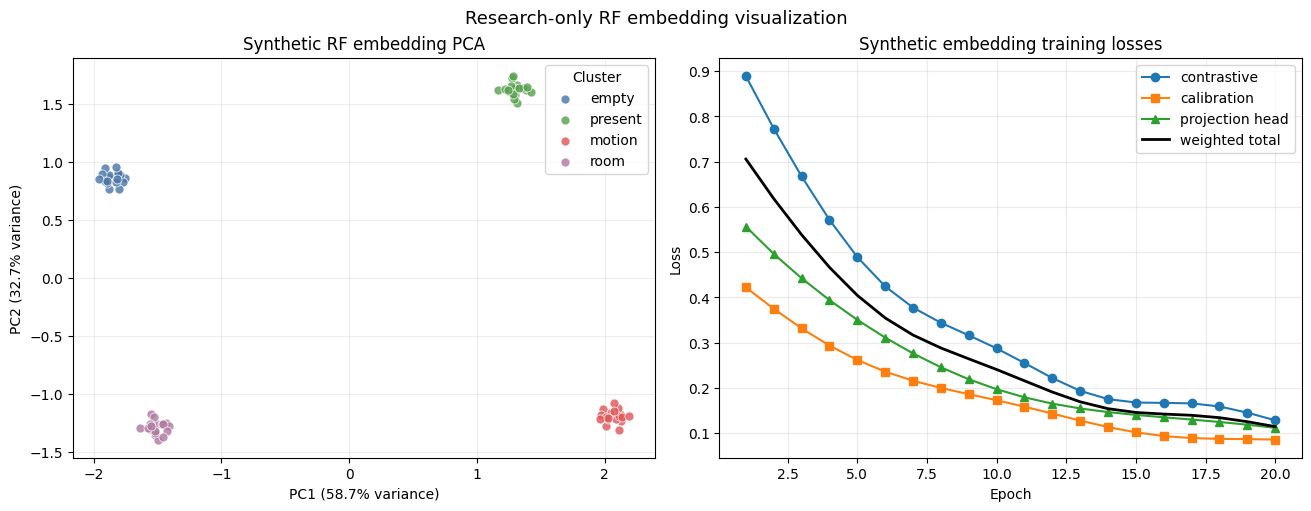

{'cluster_means_pc': {'empty': [-1.854, 0.86], 'present': [1.298, 1.628], 'motion': [2.065, -1.195], 'room': [-1.509, -1.293]}, 'rooms': [0, 1, 2]}


In [3]:
embeddings, labels, rooms = make_synthetic_embeddings()
coords, explained = pca_2d(embeddings)
epochs, contrastive_loss, calibration_loss, projection_loss, total_loss = synthetic_training_curves()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

for label in CLUSTERS:
    mask = labels == label
    axes[0].scatter(
        coords[mask, 0],
        coords[mask, 1],
        s=42,
        alpha=0.82,
        label=label,
        color=COLORS[label],
        edgecolor="white",
        linewidth=0.6,
    )
axes[0].set_title("Synthetic RF embedding PCA")
axes[0].set_xlabel(f"PC1 ({explained[0] * 100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({explained[1] * 100:.1f}% variance)")
axes[0].legend(title="Cluster", loc="best")
axes[0].grid(True, alpha=0.22)

axes[1].plot(epochs, contrastive_loss, marker="o", label="contrastive")
axes[1].plot(epochs, calibration_loss, marker="s", label="calibration")
axes[1].plot(epochs, projection_loss, marker="^", label="projection head")
axes[1].plot(epochs, total_loss, color="black", linewidth=2.0, label="weighted total")
axes[1].set_title("Synthetic embedding training losses")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.25)

fig.suptitle("Research-only RF embedding visualization", fontsize=13)
plt.show()

cluster_means = {label: coords[labels == label].mean(axis=0).round(3).tolist() for label in CLUSTERS}
print({"cluster_means_pc": cluster_means, "rooms": sorted(set(rooms.tolist()))})


Expected interpretation: the four clusters should remain separated in the first two principal components. The loss plot mirrors the kind of contrastive, calibration, and projection-head diagnostics expected from a future optional PyTorch training run.

Limitations: PCA uses sklearn when available and NumPy SVD otherwise. No real RF encoder, triplet sampler, checkpoint, UMAP, t-SNE, or PyTorch module is executed here.
